In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os


In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
features = ["score_difference", "relative_strength"]
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data

training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017,2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win")

validation_data = process_data.load_data(interpolated_dir, 
                                       years = [2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = True
                                       )
                                       
test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )




/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [3]:
# Get information about the data
for timestep in training_data:
    print(f"timestep: {timestep}, number of instances: {len(training_data[timestep])}")

timestep: 0.0, number of instances: 3770
timestep: 0.005, number of instances: 1266
timestep: 0.01, number of instances: 2484
timestep: 0.015, number of instances: 2093
timestep: 0.02, number of instances: 2305
timestep: 0.025, number of instances: 2402
timestep: 0.03, number of instances: 2268
timestep: 0.035, number of instances: 2493
timestep: 0.04, number of instances: 2351
timestep: 0.045, number of instances: 2519
timestep: 0.05, number of instances: 2467
timestep: 0.055, number of instances: 2331
timestep: 0.06, number of instances: 2576
timestep: 0.065, number of instances: 2491
timestep: 0.07, number of instances: 2528
timestep: 0.075, number of instances: 2458
timestep: 0.08, number of instances: 2541
timestep: 0.085, number of instances: 2573
timestep: 0.09, number of instances: 2450
timestep: 0.095, number of instances: 2562
timestep: 0.1, number of instances: 2549
timestep: 0.105, number of instances: 2494
timestep: 0.11, number of instances: 2568
timestep: 0.115, number o

In [4]:
# Straw men tests
# - Initial probability
# - Coin toss at the start
# - Coin toss at each time step
from typing import Dict, Any
from models.Model import Model


class InitialProbabilityModel(Model):
    def __init__(self, features, label_feature):
        super().__init__(use_calibration=False, optimize_hyperparams=False, numeric_features=None, other_features=features, all_features=features, n_trials=0)
    

    def _define_search_space(self, trial) -> Dict[str, Any]:
        """Return a dict of parameters sampled from the search space."""
        return {}

    def _fixed_params(self) -> Dict[str, Any]:
        """Optional fixed params to merge into search params (subclass may override)."""
        return {}

    def _train_model(self, x_train, y_train, x_val, y_val, params):
        return None

    def fit(self, X, y):
        self._train_model()
    def predict(self, X: np.ndarray) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs > 0.5).astype(int)
    
    def predict_proba(self, X):
        relative_strength_idx = self.all_features.index("relative_strength")
        relative_strength = X[:, relative_strength_idx]
        return np.array([[1-s, s] for s in relative_strength])


class CoinFlipModel(Model):
    def __init__(self):
        super().__init__(use_calibration=False, optimize_hyperparams=False, numeric_features=None, other_features=None, all_features=None, n_trials=0)

    def _define_search_space(self, trial) -> Dict[str, Any]:
        """Return a dict of parameters sampled from the search space."""
        return {}

    def _fixed_params(self) -> Dict[str, Any]:
        """Optional fixed params to merge into search params (subclass may override)."""
        return {}

    def _train_model(self, x_train, y_train, x_val, y_val, params):
        return None

    def fit(self, X, y):
        self._train_model()
    def predict(self, X: np.ndarray) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs > 0.5).astype(int)
    
    def predict_proba(self, X):
        n = X.shape[0]
        random_choices = np.random.choice([0, 1], size=n)
        # For each row, output [1, 0] if random choice is 0; [0, 1] if random choice is 1
        return np.array([[1, 0] if r == 0 else [0, 1] for r in random_choices])

In [5]:
def setup_initial_probability_models(features):
    models = {}
    for timestep in training_data:
        model = InitialProbabilityModel(features, "home_win")
        models[timestep] = model
    return models

def setup_coin_flip_models():
    models = {}
    for timestep in training_data:
        model = CoinFlipModel()
        models[timestep] = model
    return models

models = setup_coin_flip_models()

In [8]:
models[0].predict_proba(np.array([[0, 0]]))

array([[1, 0]])

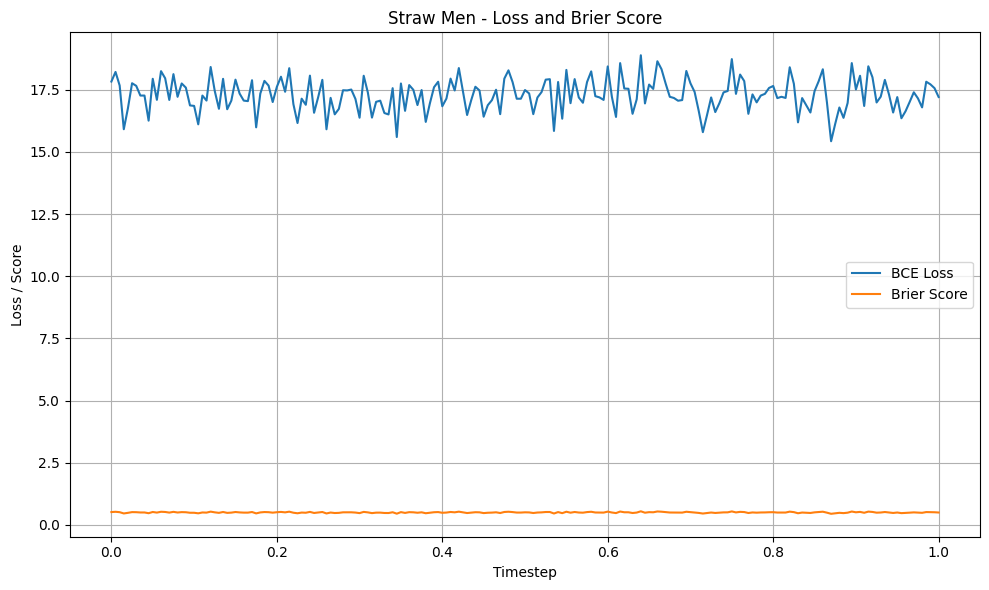

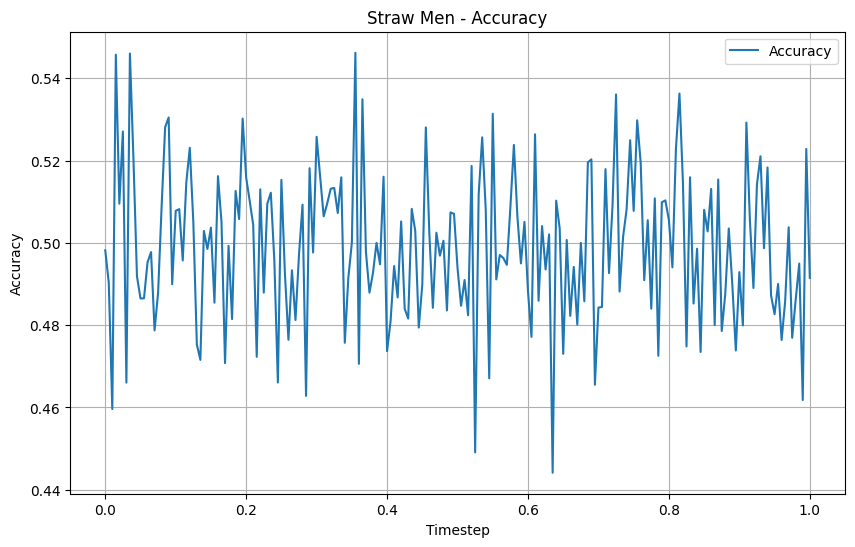

In [9]:
import process_data
modules_to_reload = [
    'process_data',
]

import importlib
for module_name in modules_to_reload:
    if module_name in globals():
        importlib.reload(globals()[module_name])
    elif module_name in locals():
        importlib.reload(locals()[module_name])
    else:
        try:
            mod = __import__(module_name)
            importlib.reload(mod)
        except Exception as e:
            print(f"Could not reload {module_name}: {e}")


import process_data

process_data.plot_loss(models, test_data, "Straw Men")
process_data.plot_accuracy(models, test_data, "Straw Men")

In [10]:
from process_data import write_predictions

write_predictions(models, interpolated_dir, [2024, 2025], 0, features, replace_nan_val = 0, phat_b = "coin_flip_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [11]:
# Always predict 1
def always_predict_1(interpolated_dir, years, phat_b = "1_phat_b"):
    # Write the predictions to csv file
    for folder in os.listdir(interpolated_dir):
        folder_path = os.path.join(interpolated_dir, folder)
        if os.path.isdir(folder_path):
            if (int(folder) in years):
                print(f"Loading data for {folder}")
                for file in os.listdir(folder_path):
                    if file.endswith(".csv"):
                        file_path = os.path.join(folder_path, file)
                        df = pd.read_csv(file_path)
                        for idx in range(1, len(df)):
                            df.at[idx, phat_b] = 1
                        df.to_csv(file_path, index=False)
                        print("Processed file: ", file)

always_predict_1(interpolated_dir, [2024, 2025])

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [12]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "always_one_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/always_one_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/always_one_model'


In [13]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "coin_flip_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/coin_flip_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/coin_flip_model'


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

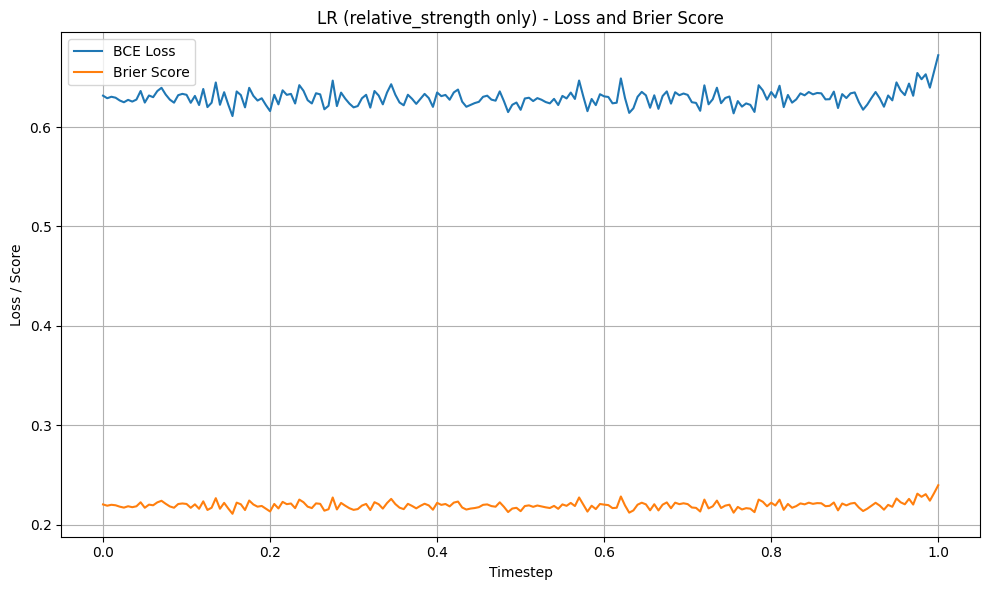

{'timesteps': [0.0,
  0.005,
  0.01,
  0.015,
  0.02,
  0.025,
  0.03,
  0.035,
  0.04,
  0.045,
  0.05,
  0.055,
  0.06,
  0.065,
  0.07,
  0.075,
  0.08,
  0.085,
  0.09,
  0.095,
  0.1,
  0.105,
  0.11,
  0.115,
  0.12,
  0.125,
  0.13,
  0.135,
  0.14,
  0.145,
  0.15,
  0.155,
  0.16,
  0.165,
  0.17,
  0.175,
  0.18,
  0.185,
  0.19,
  0.195,
  0.2,
  0.205,
  0.21,
  0.215,
  0.22,
  0.225,
  0.23,
  0.235,
  0.24,
  0.245,
  0.25,
  0.255,
  0.26,
  0.265,
  0.27,
  0.275,
  0.28,
  0.285,
  0.29,
  0.295,
  0.3,
  0.305,
  0.31,
  0.315,
  0.32,
  0.325,
  0.33,
  0.335,
  0.34,
  0.345,
  0.35,
  0.355,
  0.36,
  0.365,
  0.37,
  0.375,
  0.38,
  0.385,
  0.39,
  0.395,
  0.4,
  0.405,
  0.41,
  0.415,
  0.42,
  0.425,
  0.43,
  0.435,
  0.44,
  0.445,
  0.45,
  0.455,
  0.46,
  0.465,
  0.47,
  0.475,
  0.48,
  0.485,
  0.49,
  0.495,
  0.5,
  0.505,
  0.51,
  0.515,
  0.52,
  0.525,
  0.53,
  0.535,
  0.54,
  0.545,
  0.55,
  0.555,
  0.56,
  0.565,
  0.57,
  0.575,
  0.58,

In [14]:

# LR straw man: relative_strength only
modules_to_reload = ['models.logistic_regression', 'models.Model']
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models.logistic_regression import setup_logistic_regression_models

rs_features = ["relative_strength"]
rs_training_data = process_data.load_data(interpolated_dir,
                                           years=[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
                                           history_length=0,
                                           features=rs_features,
                                           label_feature="home_win")
rs_test_data = process_data.load_data(interpolated_dir,
                                       years=[2024, 2025],
                                       history_length=0,
                                       features=rs_features,
                                       label_feature="home_win",
                                       train=False)

rs_models = setup_logistic_regression_models(rs_training_data, None, rs_features, [], rs_features,
                                              optimize_hyperparams=False, use_calibration=False)

process_data.plot_loss(rs_models, rs_test_data, "LR (relative_strength only)")


In [15]:
from process_data import write_predictions
write_predictions(rs_models, interpolated_dir, [2024, 2025], 0, rs_features, replace_nan_val=0, phat_b="LR_rs_phat_b")

import shutil
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025"),
]
destination = os.path.join(dest_dir, "test_final", "LR_rs_model")
for source in sources:
    if os.path.exists(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")


Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

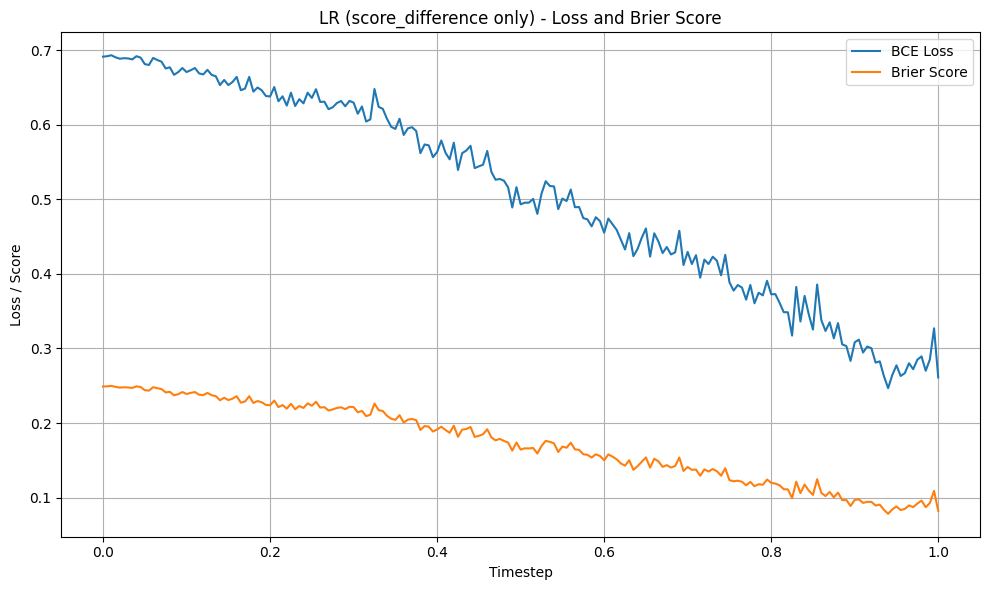

{'timesteps': [0.0,
  0.005,
  0.01,
  0.015,
  0.02,
  0.025,
  0.03,
  0.035,
  0.04,
  0.045,
  0.05,
  0.055,
  0.06,
  0.065,
  0.07,
  0.075,
  0.08,
  0.085,
  0.09,
  0.095,
  0.1,
  0.105,
  0.11,
  0.115,
  0.12,
  0.125,
  0.13,
  0.135,
  0.14,
  0.145,
  0.15,
  0.155,
  0.16,
  0.165,
  0.17,
  0.175,
  0.18,
  0.185,
  0.19,
  0.195,
  0.2,
  0.205,
  0.21,
  0.215,
  0.22,
  0.225,
  0.23,
  0.235,
  0.24,
  0.245,
  0.25,
  0.255,
  0.26,
  0.265,
  0.27,
  0.275,
  0.28,
  0.285,
  0.29,
  0.295,
  0.3,
  0.305,
  0.31,
  0.315,
  0.32,
  0.325,
  0.33,
  0.335,
  0.34,
  0.345,
  0.35,
  0.355,
  0.36,
  0.365,
  0.37,
  0.375,
  0.38,
  0.385,
  0.39,
  0.395,
  0.4,
  0.405,
  0.41,
  0.415,
  0.42,
  0.425,
  0.43,
  0.435,
  0.44,
  0.445,
  0.45,
  0.455,
  0.46,
  0.465,
  0.47,
  0.475,
  0.48,
  0.485,
  0.49,
  0.495,
  0.5,
  0.505,
  0.51,
  0.515,
  0.52,
  0.525,
  0.53,
  0.535,
  0.54,
  0.545,
  0.55,
  0.555,
  0.56,
  0.565,
  0.57,
  0.575,
  0.58,

In [16]:

# LR straw man: score_difference only
sd_features = ["score_difference"]
sd_training_data = process_data.load_data(interpolated_dir,
                                           years=[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
                                           history_length=0,
                                           features=sd_features,
                                           label_feature="home_win")
sd_test_data = process_data.load_data(interpolated_dir,
                                       years=[2024, 2025],
                                       history_length=0,
                                       features=sd_features,
                                       label_feature="home_win",
                                       train=False)

sd_models = setup_logistic_regression_models(sd_training_data, None, [], sd_features, sd_features,
                                              optimize_hyperparams=False, use_calibration=False)

process_data.plot_loss(sd_models, sd_test_data, "LR (score_difference only)")


In [17]:

write_predictions(sd_models, interpolated_dir, [2024, 2025], 0, sd_features, replace_nan_val=0, phat_b="LR_sd_phat_b")

src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025"),
]
destination = os.path.join(dest_dir, "test_final", "LR_sd_model")
for source in sources:
    if os.path.exists(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")


Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces